# The Transformation and Accept/Reject (aka. Von Neumann) methods 
Python notebook with exercise on how to generate random numbers following a specific PDF using uniformly distributed random numbers, in this case a third degree polynomial: $f(x) = x^3$, in the interval $[0, C]$ where $C$ is a number that ensures that the function if properly normalized.

Both the Accept-Reject (Von Neumann) and transformation method should be considered for the problem:
- Transformation method (if function can be integrated and then inverted).
- Accept-Reject (or Hit & Miss) method (by Ulam Stanislav and John Von Neumann).

### References:
- G. Cowan: Chapter 3
- P. R. Bevington: page 81-84
- __[40. Monte Carlo Techniques PDG](https://pdg.lbl.gov/2023/reviews/rpp2023-rev-monte-carlo-techniques.pdf)__

### Authors: 
- Troels C. Petersen (Niels Bohr Institute)

### Date:    
- 30-11-2025 (latest update)

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit, cost
from scipy import stats
plt.rcParams['font.size'] = 18     # Set some basic plotting parameters

set the parameters of the program:

In [2]:
r = np.random
r.seed(42)

save_plots = False  
N_points = 10000      # Number of random points used 

xmin = 0
xmax = 1.0            # Find out yourself what a good interval is.
N_bins = 100          # Find out yourself what a good number of bins is.

# f(x):
def fx_x3(x) :
    # Normalization is N_points * binwidth:
    k = (xmax - xmin) / N_bins
    N = N_points * k
    return x**3*4*N

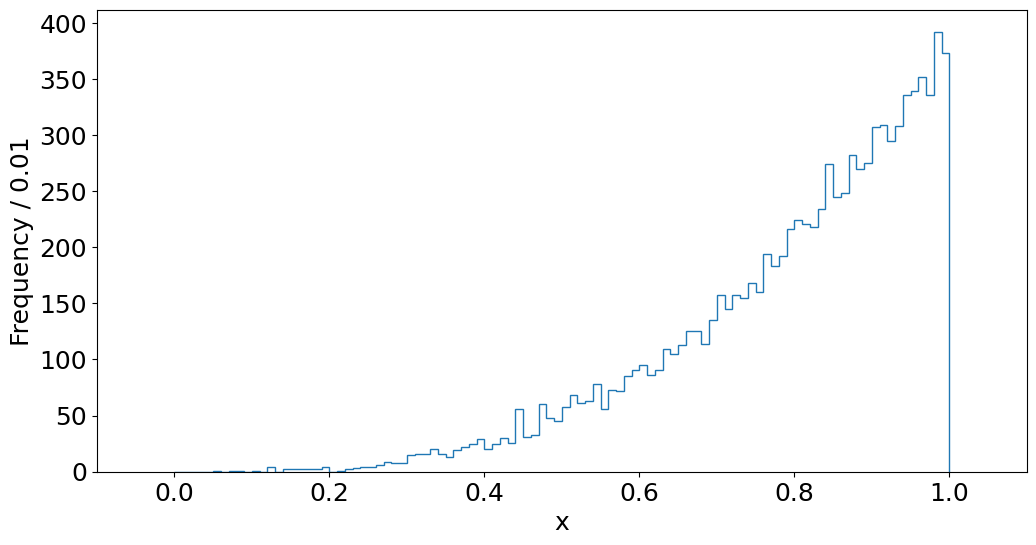

In [3]:
from scipy.integrate import quad

quad(fx_x3 , 0, 1)

x_transformation = np.sqrt(np.sqrt(r.uniform(size=N_points)))

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.hist(x_transformation, bins=N_bins, range=(xmin, xmax), histtype='step', label='histogram' )
ax1.set(xlabel="x", ylabel="Frequency / 0.01", xlim=(xmin-0.1, xmax+0.1));


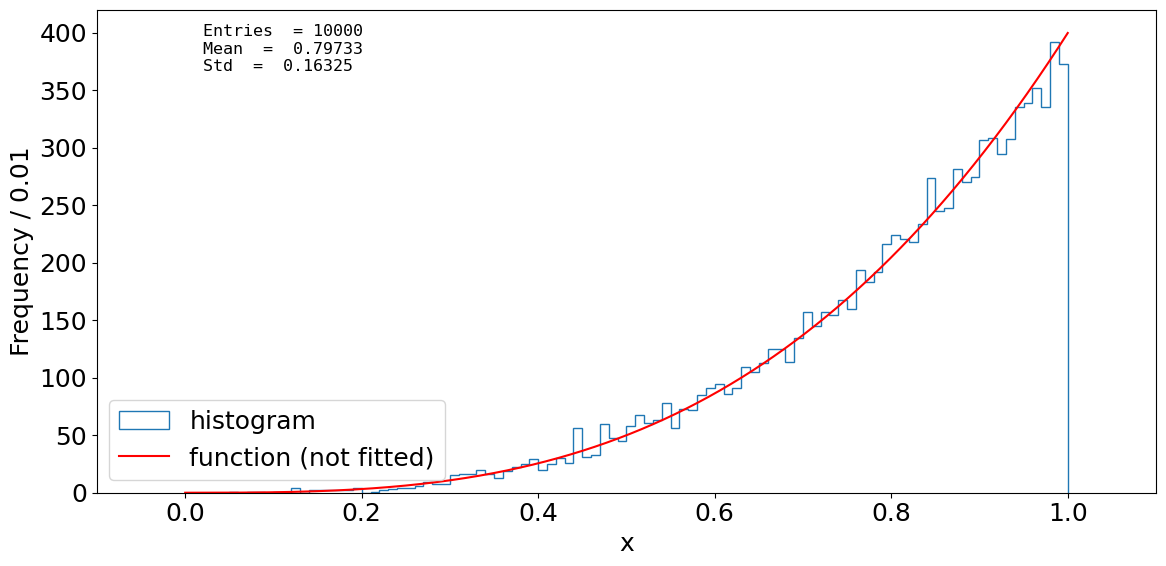

In [4]:
# Plot f(x)
x_axis1 = np.linspace(xmin, xmax, N_points)
y_axis1 = fx_x3(x_axis1)
#print(x_axis1, y_axis1)

ax1.plot(x_axis1, y_axis1, 'r-', label='function (not fitted)')

# Define figure text
plot_info = ['Entries  = ' + f"{len(x_transformation)}",
     'Mean  =  ' + f"{x_transformation.mean():3.5f}",
     'Std  =  '+ f"{x_transformation.std(ddof=1):3.5f}",
]

# Plot figure text
ax1.text(0.1, 0.97, "\n".join(plot_info), family='monospace', fontsize=12, verticalalignment='top',transform=ax1.transAxes)

# Add legend
ax1.legend(loc='best')
fig1.tight_layout()

# Show the figure
fig1

AttributeError: 'Figure' object has no attribute 'plot'

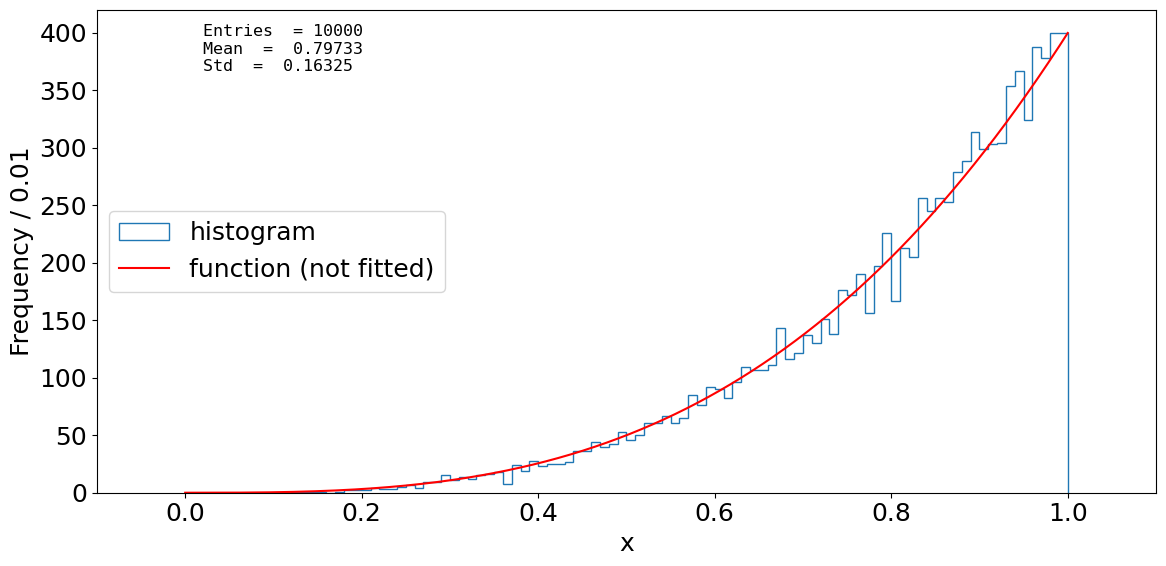

In [9]:
x_accepted       = np.zeros(N_points)

for i in range(N_points):
    while True:
        x_rand=r.uniform(xmin, xmax)
        y_rand=r.uniform(0,4)
        if (4*x_rand**3>y_rand):
            break
    x_accepted[i]=x_rand


fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.hist(x_accepted, bins=N_bins, range=(xmin, xmax), histtype='step', label='histogram' )
ax2.set(xlabel="x", ylabel="Frequency / 0.01", xlim=(xmin-0.1, xmax+0.1));

In [ ]:

# Plot f(x)
x_axis2 = np.linspace(xmin, xmax, N_points)
y_axis2 = fx_x3(x_axis2)
#print(x_axis1, y_axis1)

ax2.plot(x_axis2, y_axis2, 'r-', label='function (not fitted)')

# Define figure text
plot_info = ['Entries  = ' + f"{len(x_transformation)}",
     'Mean  =  ' + f"{x_transformation.mean():3.5f}",
     'Std  =  '+ f"{x_transformation.std(ddof=1):3.5f}",
]

# Plot figure text
ax2.text(0.1, 0.97, "\n".join(plot_info), family='monospace', fontsize=12, verticalalignment='top',transform=ax2.transAxes)

# Add legend
ax2.legend(loc='best')
fig2.tight_layout()

# Show the figure
fig2

In [6]:
#fit

min

#delta

#plot delta vs x

<function min>

## Problem: 

1) Calculate $C$ such that f(x) is normalised [Analytical problem].

2) Calculate the relevant integral (below) and inverted function for using the transformation method. Check that the limits actually makes sense [Analytical problem]. Note that it is important to include the limits!

$$F(x) = \int_{-\infty}^{x} f(x') dx'$$

3) Produce random points following $f(x) = x^3$, in the interval $[0, C]$ using **both** the Transformation and the Accept/Reject method.

4) Fit your data with a third degree polynomial, and check that the coefficients correspond to what you would expect.

5) Now try to change the interval from [0,C] to [1,C], and see how the limits change.

# Learning points:

As a basic principle, this exercise should make you capable of using two methods for generating random numbers according to a 1D PDF f(x) based on uniform random numbers (provided by a standard algorithm):
1. Transformation method (using integral+inverse of f(x))
2. Accept-Reject method (using sampling in 2D compared to f(x))

You should know:
1. The advantages and limitations of each method.
2. How to get the desired result out of each method.

Finally, you should understand the motivation behind generating random numbers according to a given distribution, namely for simulating complicated situations (e.g. experimental setup), and evaluating the outcome.